# A Simple Neural Network Making a Prediction

### What is a Neural Network?

In [5]:
# The network:

weight = 0.1 
def neural_network(input, weight):
    prediction = input * weight
    return prediction

# How we use the network to predict something:

number_of_toes = [8.5, 9.5, 10, 9]
input = number_of_toes[0]
pred = neural_network(input,weight)
print(pred)

0.8500000000000001


# Making a Prediction with Multiple Inputs

### Complete Runnable Code

In [10]:
def w_sum(a, b):
    assert(len(a) == len(b))
    output = 0
    for i in range(len(a)):
        output += (a[i] * b[i])
    return output

weights = [0.1, 0.2, 0] 
    
def neural_network(input, weights):
    pred = w_sum(input, weights)
    return pred

# This dataset is the current
# status at the beginning of
# each game for the first 4 games
# in a season.

# toes = current number of toes
# wlrec = current games won (percent)
# nfans = fan count (in millions)

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

# Input corresponds to every entry
# for the first game of the season.

input = [toes[0],wlrec[0],nfans[0]]
pred = neural_network(input, weights)

print(pred)

0.9800000000000001


In [11]:
w_sum([1, 2, 3], [1, 2, 30])

95

### NumPy Code

In [12]:
import numpy as np

weights = np.array([0.1, 0.2, 0])

def neural_network(input, weights):
    pred = input.dot(weights)
    return pred
    
toes =  np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

# Input corresponds to every entry
# for the first game of the season.

input = np.array([toes[0],wlrec[0],nfans[0]])
pred = neural_network(input,weights)

print(pred)

0.9800000000000001


# Making a Prediction with Multiple Outputs

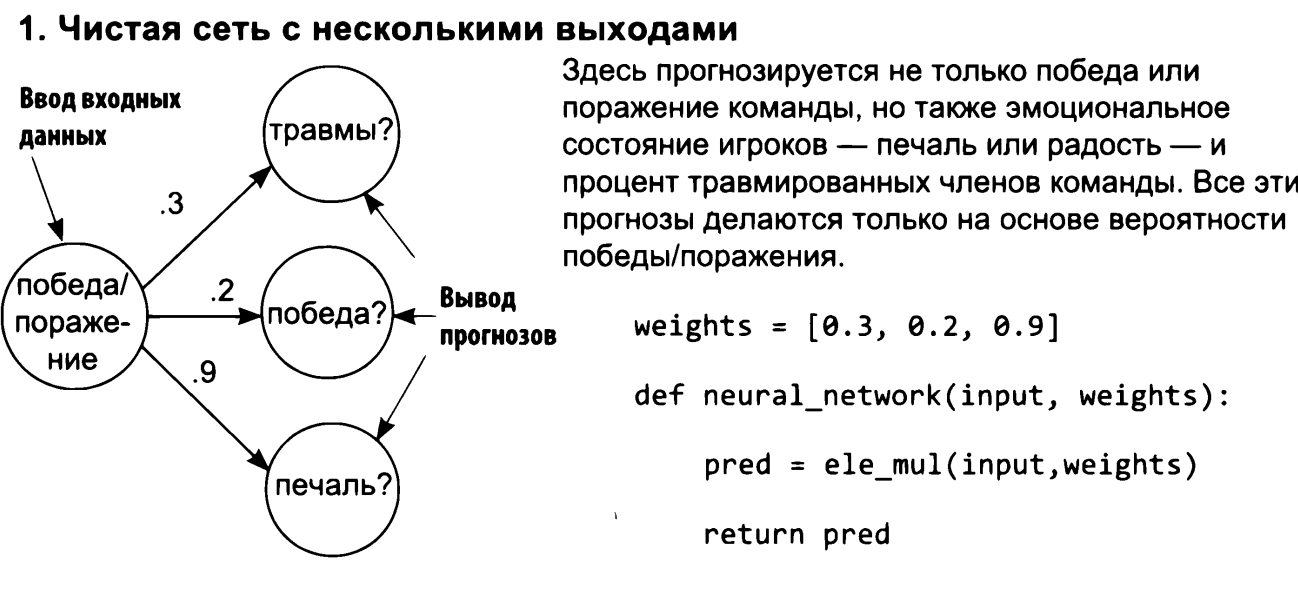

In [13]:
# Instead of predicting just 
# whether the team won or lost, 
# now we're also predicting whether
# they are happy/sad AND the percentage
# of the team that is hurt. We are
# making this prediction using only
# the current win/loss record.

def ele_mul(number, vector):
    output = [0, 0, 0]
    assert(len(output) == len(vector))
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.3, 0.2, 0.9] 

def neural_network(input, weights):
    pred = ele_mul(input, weights)
    return pred
    
wlrec = [0.65, 0.8, 0.8, 0.9]
input = wlrec[0]
pred = neural_network(input, weights)

print(pred)

[0.195, 0.13, 0.5850000000000001]


# Predicting with Multiple Inputs & Outputs

Тут всё перевёрнуто, быть аккруатнее с интерпретацией, косяк автора. Матрицу стоило транспонировать, для показательности и сравнения с Numpy.

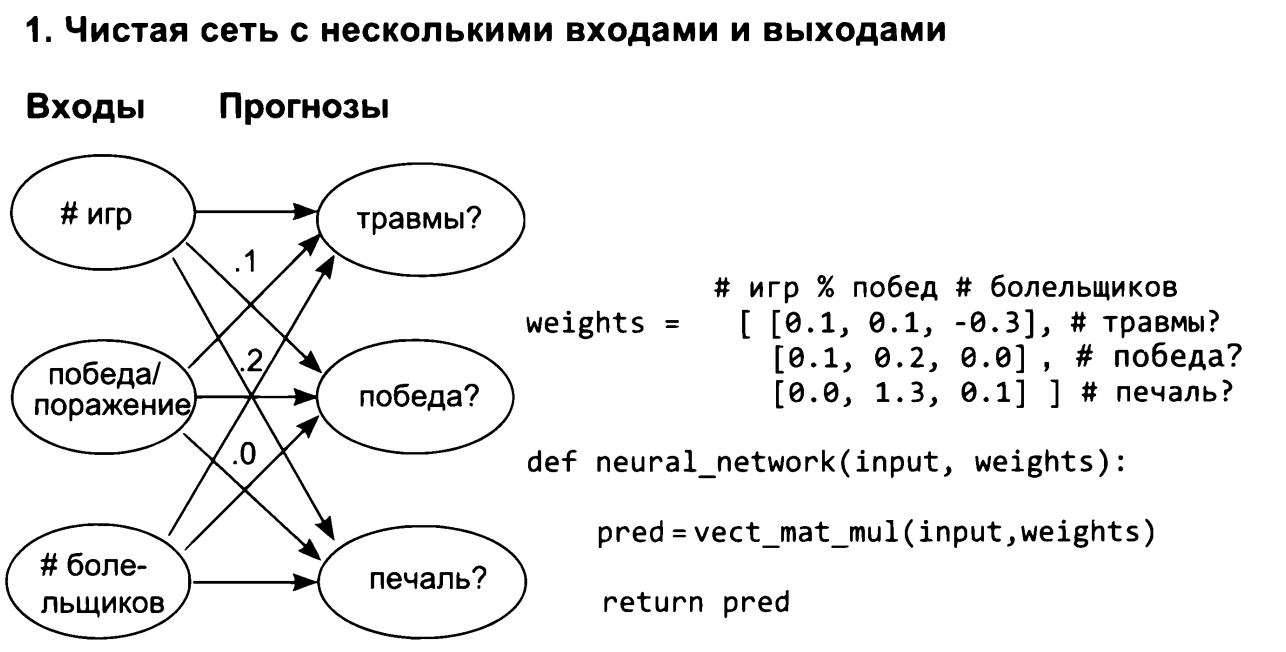

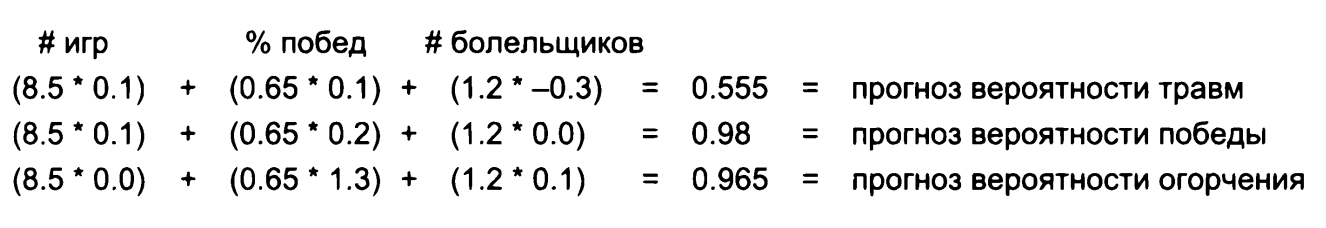

In [46]:
def w_sum(a, b):
    assert(len(a) == len(b))
    output = 0
    for i in range(len(a)):
        output += (a[i] * b[i])
    return output

def vect_mat_mul(vect, matrix):
    assert(len(vect) == len(matrix))
    output = [0, 0, 0]
    for i in range(len(vect)):
        output[i] = w_sum(vect, matrix[i])
    return output

def neural_network(input, weights):
    pred = vect_mat_mul(input, weights)
    return pred

# This dataset is the current
# status at the beginning of
# each game for the first 4 games
# in a season.

# toes = current number of toes
# wlrec = current games won (percent)
# nfans = fan count (in millions)

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65,0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

            # toes # win # fans
weights = [ [0.1, 0.1, -0.3], # hurt?
            [0.1, 0.2, 0.0], # win?
            [0.0, 1.3, 0.1] ] # sad?

# Input corresponds to every entry
# for the first game of the season.
input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)

print(pred)

[0.555, 0.9800000000000001, 0.9650000000000001]


# Predicting on Predictions

In [33]:
            #toes %win #fans
ih_wgt = [ [0.1, 0.2, -0.1], # hid[0]
           [-0.1,0.1, 0.9], # hid[1]
           [0.1, 0.4, 0.1] ] # hid[2]

           #hid[0] hid[1] hid[2]
hp_wgt = [ [0.3, 1.1, -0.3], # hurt?
           [0.1, 0.2, 0.0], # win?
           [0.0, 1.3, 0.1] ] # sad?

weights = [ih_wgt, hp_wgt]


def vect_mat_mul(vect, matrix):
    assert(len(vect) == len(matrix))
    output = [0, 0, 0]
    for i in range(len(vect)):
        output[i] = w_sum(vect, matrix[i])
    return output


def neural_network(input, weights):
    hid = vect_mat_mul(input, weights[0])
    print(hid)
    pred = vect_mat_mul(hid, weights[1])
    return pred

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65,0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

# Input corresponds to every entry
# for the first game of the season.

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)

print(pred)

[0.8600000000000001, 0.29499999999999993, 1.23]
[0.21350000000000002, 0.14500000000000002, 0.5065]


# NumPy Version

In [51]:
import numpy as np

#toes %win #fans
ih_wgt = np.array([ 
            [0.1, 0.2, -0.1], #hid[0]
            [-0.1 ,0.1, 0.9], #hid[1]
            [0.1, 0.4, 0.1]]).T #hid[2]


# hid[0] hid[1] hid[2]
hp_wgt = np.array([  
            [0.3, 1.1, -0.3], #hurt?
            [0.1, 0.2, 0.0], #win?
            [0.0, 1.3, 0.1] ]).T #sad?

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
    hid = input.dot(weights[0])
    print("hide out:", hid)
    pred = hid.dot(weights[1])
    return pred


toes =  np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65,0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0], wlrec[0], nfans[0]])

pred = neural_network(input, weights)
print("pred:", pred)

hide out: [0.86  0.295 1.23 ]
pred: [0.2135 0.145  0.5065]


# A Quick Primer on NumPy

In [52]:
import numpy as np

a = np.array([0,1,2,3]) # a vector
b = np.array([4,5,6,7]) # another vector
c = np.array([[0,1,2,3], # a matrix
              [4,5,6,7]])

d = np.zeros((2,4)) # (2x4 matrix of zeros)
e = np.random.rand(2,5) # random 2x5
# matrix with all numbers between 0 and 1

print(a)
print(b)
print(c)
print(d)
print(e)

[0 1 2 3]
[4 5 6 7]
[[0 1 2 3]
 [4 5 6 7]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[2.93332772e-01 7.33818324e-01 4.92518308e-01 1.58980828e-01
  9.90130932e-01]
 [9.86457276e-01 1.79005153e-01 2.90861254e-04 9.92184868e-01
  8.32084872e-01]]


In [53]:
print(a * 0.1) # multiplies every number in vector "a" by 0.1
      
print(c * 0.2) # multiplies every number in matrix "c" by 0.2
      
print(a * b) # multiplies elementwise between a and b (columns paired up)
      
print(a * b * 0.2) # elementwise multiplication then multiplied by 0.2
      
print(a * c) # since c has the same number of columns as a, this performs
# elementwise multiplication on every row of the matrix "c"

print(a * e) # since a and e don't have the same number of columns, this
# throws a "Value Error: operands could not be broadcast together with.."

[0.  0.1 0.2 0.3]
[[0.  0.2 0.4 0.6]
 [0.8 1.  1.2 1.4]]
[ 0  5 12 21]
[0.  1.  2.4 4.2]
[[ 0  1  4  9]
 [ 0  5 12 21]]


ValueError: operands could not be broadcast together with shapes (4,) (2,5) 

In [54]:
a = np.zeros((1,4)) # vector of length 4
b = np.zeros((4,3)) # matrix with 4 rows & 3 columns

c = a.dot(b)
print(c.shape)

(1, 3)


In [55]:
a = np.zeros((2,4)) # matrix with 2 rows and 4 columns
b = np.zeros((4,3)) # matrix with 4 rows & 3 columns

c = a.dot(b)
print(c.shape) # outputs (2,3)

e = np.zeros((2,1)) # matrix with 2 rows and 1 columns
f = np.zeros((1,3)) # matrix with 1 row & 3 columns

g = e.dot(f)
print(g.shape) # outputs (2,3)

h = np.zeros((5,4)).T # matrix with 4 rows and 5 columns
i = np.zeros((5,6)) # matrix with 6 rows & 5 columns

j = h.dot(i)
print(j.shape) # outputs (4,6)

h = np.zeros((5,4)) # matrix with 5 rows and 4 columns
i = np.zeros((5,6)) # matrix with 5 rows & 6 columns
j = h.dot(i)
print(j.shape) # throws an error

(2, 3)
(2, 3)
(4, 6)


ValueError: shapes (5,4) and (5,6) not aligned: 4 (dim 1) != 5 (dim 0)